# Wstępna eksploracyjna analiza danych (EDA) - Etap 2. projektu

Zbiór danych ["Default of Credit Card Clients"](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)


## Krok 1: Weryfikacja jakości i czyszczenie danych

### Wczytanie danych

In [16]:
DATASET_PATH = "../data/default_of_credit_card_clients.xls"

data = pd.read_excel(DATASET_PATH)


In [17]:
data.columns


Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [18]:
data.head()


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


### Zmiana nazw kolumn

In [19]:
### Rename column header to more meaningful variable names ("Description" in the "Variables Table" at the dataset website)
variable_names = data.iloc[0].values
variable_names


array(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6', 'default payment next month'], dtype=object)

In [24]:
data = data.iloc[1:].copy() # skip the 1st row
data.columns = variable_names
data = data.reset_index(drop=True)

data.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
3,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False


### Konwersja i sprawdzenie typów zmiennych

In [25]:
print("Typy danych przed konwersją:")
data.dtypes


Typy danych przed konwersją:


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month     bool
dtype: object

In [22]:
# Infer column types based on column values
data = data.infer_objects()

# set the type of the last variable (target) to bool
data = data.astype({variable_names[-1]: bool})


In [26]:
print(f"Typy danych po konwersji:\n{data.dtypes}")


Typy danych po konwersji:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month     bool
dtype: object


### Sprawdzenie struktury zbioru danych

In [27]:
print(f"Zbiór danych zawiera {data.shape[0]} wierszy i {data.shape[1]} kolumn")


Zbiór danych zawiera 29999 wierszy i 25 kolumn


### Sprawdzenie brakujących wartości i zduplikowanych wierszy

In [28]:
# Sprawdzenie czy zbiór danych zawiera brakujące wartości (NaN)
missing = data.isnull().sum()
missing_result = "nie zawiera" if missing.sum() == 0 else f"zawiera {missing.sum()}"

print(f"Zbiór danych {missing_result} brakujących wartości")

Zbiór danych nie zawiera brakujących wartości


In [29]:
# Sprawdzenie czy zbiór danych zawiera zduplikowane wiersze
duplicated = data.duplicated().sum()
duplicated_result = "nie zawiera" if duplicated == 0 else f"zawiera {duplicated}"

print(f"Zbior danych {duplicated_result} zduplikowanych wierszy")

Zbior danych nie zawiera zduplikowanych wierszy


### Znaczenie kolumn w zbiorze danych

Wszystkie kwoty są podane w dolarach tajwańskich


| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X1             | LIMIT_BAL | Kwota udzielonego kredytu |
| X2             | SEX | Płeć (1 = mężczyzna, 2 = kobieta) |
| X3             | EDUCATION | Wykształcenie (1 = studia podyplomowe, 2 = studia wyższe, 3 = szkoła średnia, 4 = inne) |
| X4             | MARRIAGE | Stan cywilny (1 = married, 2 = single, 3 = others) |
| X5             | AGE | Wiek |


Zmienne **X6 - X11**: Historia spłat (od kwietnia do września 2005r.)

Status spłaty (-1 = spłata terminowa, 1 = opóżnienie płatności o jeden miesiąc, 2 = opóżnienie płatności o dwa miesiące, ..., 8 = opóźnienie płatności o osiem miesięcy, 9 = opóźnienie płatności o dziewięć miesięcy i więcej)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X6             | PAY_0 | Status spłaty we wrześniu 2005r. |
| X7             | PAY_2 | Status spłaty w sierpniu 2005r. |
| X8             | PAY_3 | Status spłaty w lipcu 2005r. |
| X9             | PAY_4 | Status spłaty w czerwcu 2005r. |
| X10            | PAY_5 | Status spłaty w maju 2005r. |
| X11            | PAY_6 | Status spłaty w kwietniu 2005r. |


Zmienne **X12 - X17**: Kwota rachunku (od kwietnia do września 2005r.)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X12            | BILL_AMT1 | Kwota rachunku we wrześniu 2005r. |
| X13            | BILL_AMT2 | Kwota rachunku w sierpniu 2005r. |
| X14            | BILL_AMT3 | Kwota rachunku w lipcu 2005r. |
| X15            | BILL_AMT4 | Kwota rachunku w czerwcu 2005r. |
| X16            | BILL_AMT5 | Kwota rachunku w maju 2005r.|
| X17            | BILL_AMT6 | Kwota rachunku w kwietniu 2005r. |

Zmienne **X18 - X23**: Kwota poprzedniej płatności (od kwietnia do września 2005r.)

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X18            | PAY_AMT1 | Kwota zapłacona we wrześniu 2005r. |
| X19            | PAY_AMT2 | Kwota zapłacona w sierpniu 2005r. |
| X20            | PAY_AMT3 | Kwota zapłacona w lipcu 2005r. |
| X21            | PAY_AMT4 | Kwota zapłacona w czerwcu 2005r. |
| X22            | PAY_AMT5 | Kwota zapłacona w maju 2005r. |
| X23            | PAY_AMT6 | Kwota zapłacona w kwietniu 2005r. |

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| Y              | default payment next month | Zaległość w spłacie (1 = Tak, 0 = Nie) |

### Sprawdzenie potencjalnych błędów w zmiennych kategorycznych

In [33]:
def find_not_allowed_values(dataset: pd.DataFrame, feature_name: str, allowed_values: list) -> pd.DataFrame:
    """
    Find all values in the specified feature (feature_name) that are not allowed in a dataset (allowed_values)
    :param dataset:
    :param feature_name:
    :param allowed_values:
    :return: DataFrame containing all non-allowed values
    """
    values_raw = pd.DataFrame(dataset[feature_name].value_counts()).T.columns.tolist()
    not_allowed_values = data[~data[feature_name].isin(allowed_values)]
    return not_allowed_values


#### Cecha Sex - #2 Zmienna

In [30]:
variable_names[2]


'SEX'

In [31]:
# Dozwolony zakres wartości dla danej cechy (1 = male; 2 = female)
sex_value_valid_range = [1, 2]

# Sprawdzenie wartości dla cechy SEX
sex_values_raw = pd.DataFrame(data[variable_names[2]].value_counts()).T
sex_values = sex_values_raw.rename(columns={1: "Male (1)", 2: "Female (2)"}, inplace=False)

print(sex_values)


SEX    Female (2)  Male (1)
count       18111     11888


In [34]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
sex_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[2],
    allowed_values=sex_value_valid_range)

if not sex_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[2]}")
    print(sex_not_allowed_values)


#### Cecha EDUCATION - #3 Zmienna

In [35]:
variable_names[3]


'EDUCATION'

In [37]:
# Dozwolony zakres wartości dla danej cechy (1 = graduate school; 2 = university; 3 = high school; 4 = others)
education_value_valid_range = [1,2, 3, 4]

# Sprawdzenie wartości dla cechy EDUCATION (Education Level)
education_values_raw = pd.DataFrame(data[variable_names[3]].value_counts()).T
education_values = education_values_raw.rename(columns={1: "graduate school (1)", 2: "university (2)", 3: "high school (3)", 4: "others (4)"}, inplace=False)

print(education_values)


EDUCATION  university (2)  graduate school (1)  high school (3)    5  \
count               14029                10585             4917  280   

EDUCATION  others (4)   6   0  
count             123  51  14  


In [38]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
education_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[3],
    allowed_values=education_value_valid_range)

if not education_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[3]} (Education Level)")
    display(education_not_allowed_values)


Dane dla nieprawidłowych wartości cechy EDUCATION (Education Level)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
46,48,150000,2,5,2,46,0,0,-1,0,0,-2,4463,3034,1170,1170,0,0,1013,1170,0,0,0,0,True
68,70,20000,1,5,2,22,2,0,0,0,0,0,18565,17204,17285,18085,11205,5982,0,1200,1000,500,1000,0,False
384,386,410000,2,5,1,42,0,0,0,0,0,0,338106,342904,344464,240865,234939,240176,15000,14000,9000,8500,9000,8300,False
501,503,230000,2,6,2,46,0,0,0,0,0,0,221590,227397,230302,186635,189896,193351,10000,9000,8000,8000,7500,7000,False
503,505,30000,1,6,1,53,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29810,29812,50000,1,5,2,46,0,0,0,-1,0,0,49336,49623,19900,19183,19563,19157,1423,1000,19183,687,696,776,False
29835,29837,180000,1,6,1,34,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
29838,29840,150000,1,5,1,36,0,0,0,0,0,0,216482,220889,133616,136378,139219,142172,5500,3800,3900,4000,4100,4100,False
29919,29921,50000,1,5,1,45,2,0,0,0,0,0,71927,73514,75373,50947,51020,0,3000,3428,2002,1023,0,0,True


#### Cecha X4 (Marital Status)

In [39]:
variable_names[4]


'MARRIAGE'

In [40]:
# Dozwolony zakres wartości dla danej cechy (1 = married; 2 = single; 3 = others)
marital_status_value_valid_range = [1,2, 3]

# Sprawdzenie wartości dla cechy MARRIAGE (Marital status )
marital_status_values = pd.DataFrame(data[variable_names[4]].value_counts()).T
marital_status_values.rename(columns={1: "married (1)", 2: "single (2)", 3: "others (3)"}, inplace=True)

print(marital_status_values)


MARRIAGE  single (2)  married (1)  others (3)   0
count          15964        13658         323  54


In [41]:
# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
marital_status_not_allowed_values = find_not_allowed_values(
    dataset=data,
    feature_name=variable_names[4],
    allowed_values=marital_status_value_valid_range)

if not marital_status_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy {variable_names[4]} (Marital Status)")
    display(marital_status_not_allowed_values)


Dane dla nieprawidłowych wartości cechy MARRIAGE (Marital Status)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
217,219,110000,2,3,0,31,0,0,0,0,0,0,89989,84229,79288,73315,63818,63208,4000,5000,3000,3000,3000,8954,False
808,810,160000,2,2,0,37,0,0,0,0,0,0,2694,38433,38870,28574,27268,28021,35888,1325,891,1000,1098,426,False
819,821,200000,2,3,0,51,-1,-1,-1,-1,0,-1,780,0,390,780,390,390,0,390,780,0,390,390,False
1018,1020,180000,2,3,0,45,-1,-1,-2,-2,-2,-2,4148,0,0,0,0,0,0,0,0,0,0,0,False
1442,1444,200000,1,3,0,51,-1,-1,-1,-1,0,-1,3556,4993,9212,2529,1036,4430,5020,9236,2529,0,4430,6398,False
2145,2147,150000,2,3,0,55,-1,-1,-1,-1,-1,-1,1080,17493,9160,2939,3396,1870,17498,9160,2939,3396,1870,6800,False
2553,2555,220000,2,1,0,33,-1,-1,-1,-1,-1,-1,3378,1531,942,608,1738,277,1531,942,608,1738,277,492,False
3055,3057,200000,1,3,0,36,-2,-2,-2,-2,-2,-2,5644,82620,14129,41359,9140,0,89187,14178,41359,9140,0,0,False
4469,4471,70000,1,3,0,35,2,2,2,2,2,2,47702,48839,49636,50517,51658,52758,2200,1900,2000,2100,2100,2000,False
5004,5006,90000,2,3,0,24,-2,-2,-2,-1,0,0,3700,20833,23968,13574,6800,1830,20108,4000,13574,14,5,13162,False


#### Cechy PAY_0, PAY_2 .. PAY_6 - Zmienne #6-#11 (Statusy Spłat)

In [46]:
# Statusy spłat - Historia spłat (od kwietnia do września 2005r.)
payment_history_features = [variable_names[i] for i in range(6, 12)]
payment_history_features


['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [50]:
# Dozwolony zakres wartości dla danej cechy:
# -1 = spłata terminowa,
# 1 = opóżnienie płatności o jeden miesiąc,
# 2 = opóżnienie płatności o dwa miesiące,
# .
# .
# .
# 8 = opóźnienie płatności o osiem miesięcy,
# 9 = opóźnienie płatności o dziewięć miesięcy i więcej
payment_status_value_valid_range = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [51]:
# Sprawdzenie wartości dla cech PAY_X (Statusy spłat)
for feature_name in payment_history_features:
    feature_values_raw = pd.DataFrame(data[feature_name].value_counts()).T
    # feature_values = feature_values_raw.rename(
    #     columns={-1: "pay duly (-1)", 1: "1 month delay (1)",2: "2 months delay (2)",
    #              3: "3 months delay (3)", 4: "4 months delay (4)", 5: "5 months delay (5)",
    #              6: "6 months delay (6)", 7: "7 months delay (7)", 8: "8 months delay (8)",
    #              9: "9 months and above delay (9)"}, inplace=False)

    print(feature_values_raw.T.sort_values(feature_name).T)
    print("\n")


PAY_0    -2    -1      0     1     2    3   4   5   6   7   8
count  2759  5686  14737  3688  2666  322  76  26  11   9  19


PAY_2    -2    -1      0   1     2    3   4   5   6   7   8
count  3782  6050  15730  28  3926  326  99  25  12  20   1


PAY_3    -2    -1      0   1     2    3   4   5   6   7   8
count  4085  5937  15764   4  3819  240  76  21  23  27   3


PAY_4    -2    -1      0   1     2    3   4   5   6   7   8
count  4348  5686  16455   2  3159  180  69  35   5  58   2


PAY_5    -2    -1      0     2    3   4   5   6   7   8
count  4545  5539  16947  2626  178  84  17   4  58   1


PAY_6    -2    -1      0     2    3   4   5   6   7   8
count  4894  5740  16286  2766  184  49  13  19  46   2




In [52]:
# Znaleznie wartości niedozwolonych w cechach X6-X11

# Sprawdzenie czy występują jakieś wartości z poza poprawnego zakresu
for feature_name in payment_history_features:
    feature_not_allowed_values = find_not_allowed_values(
        dataset=data,
        feature_name=feature_name,
        allowed_values=payment_status_value_valid_range)

    if not feature_not_allowed_values.empty:
        print(f"Dane dla nieprawidłowych wartości cechy {feature_name}")
        display(feature_not_allowed_values)
        print("=" * 50, "\n")


Dane dla nieprawidłowych wartości cechy PAY_0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
5,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
6,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29989,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29991,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29992,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29994,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy PAY_2


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
3,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
5,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29987,29989,250000,1,1,1,34,0,0,0,0,0,0,279640,252913,243075,245750,175005,179687,65000,8800,9011,6000,7000,6009,False
29989,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29991,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29994,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy PAY_3


...

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
3,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29991,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29992,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29994,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29997,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy PAY_5


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
3,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29995,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29996,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True
29997,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy PAY_6


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
2,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
3,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
4,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
5,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29992,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29994,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29995,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29996,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True


### Data Cleaning

In [65]:
# Czyszczenie zmiennej EDUCATION (Education Level)
# utworzenie nowej czystej zmiennej - zamiana 0, 5, 6 na 4 (inne)
data[f"{variable_names[3]}_CLEAN"] = data[variable_names[3]].replace({0: 4, 5: 4, 6: 4})

# Czyszczenie zmiennej MARRIAGE (Marital Status)
# utworzenie nowej czystej zmiennej - zamiana 0 na 3 (inne)
data[f"{variable_names[4]}_CLEAN"] = data[variable_names[4]].replace({0: 3})

# Zapisanie nazw oczyszczonych zmiennych kategorycznych
cleaned_categorical_variable_names = []
cleaned_categorical_variable_names.append(f"{variable_names[3]}_CLEAN")
cleaned_categorical_variable_names.append(f"{variable_names[4]}_CLEAN")

# Sprawdzenie czy operacja się powiodła
print(f"Wartości po czyszczeniu {variable_names[3]} (nowa oczyszczona zmienna [{f"{variable_names[3]}_CLEAN"}]):",
      data[f"{variable_names[3]}_CLEAN"].sort_values().unique())
print(f"Wartości po czyszczeniu {variable_names[4]} (nowa oczyszczona zmienna [{f"{variable_names[4]}_CLEAN"}]):",
      data[f"{variable_names[4]}_CLEAN"].sort_values().unique())


Wartości po czyszczeniu EDUCATION (nowa oczyszczona zmienna [EDUCATION_CLEAN]): [1 2 3 4]
Wartości po czyszczeniu MARRIAGE (nowa oczyszczona zmienna [MARRIAGE_CLEAN]): [1 2 3]


## Krok 2: Statystyki opisowe

In [66]:
# Zmienne nienumeryczne - ID, zmienne kategoryczne, zmienna docelowa (default payment next month)
not_numeric_cols = [variable_names[i] for i in range(0, 5) if i != 1]
not_numeric_cols += payment_history_features
not_numeric_cols.append(variable_names[-1])
not_numeric_cols


['ID',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'default payment next month']

In [68]:
# Zmienne numeryczne
numeric_cols = data.drop(not_numeric_cols + cleaned_categorical_variable_names, axis=1).columns.tolist()
numeric_cols


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [69]:
# Statystyki dla zmiennych numerycznych
numeric_stat = data[numeric_cols].describe().T
numeric_stat


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29999.0,167489.238975,129747.029798,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,29999.0,35.485883,9.217819,21.0,28.0,34.0,41.0,79.0
BILL_AMT1,29999.0,51224.907964,73636.581260,-165580.0,3558.5,22382.0,67092.0,964511.0
BILL_AMT2,29999.0,49180.611120,71174.457875,-69777.0,2984.5,21203.0,64008.5,983931.0
BILL_AMT3,29999.0,47014.698990,69350.027544,-157264.0,2667.5,20089.0,60165.5,1664089.0
BILL_AMT4,29999.0,43264.391113,64333.443473,-170000.0,2328.0,19052.0,54509.0,891586.0
BILL_AMT5,29999.0,40312.744725,60797.723604,-81334.0,1763.5,18105.0,50196.0,927171.0
BILL_AMT6,29999.0,38873.056169,59554.677258,-339603.0,1256.0,17074.0,49200.5,961664.0
PAY_AMT1,29999.0,5663.769292,16563.524146,0.0,1000.0,2100.0,5006.0,873552.0
PAY_AMT2,29999.0,5921.337911,23041.234635,0.0,833.0,2009.0,5000.0,1684259.0


## Krok 3: Analiza rozkładów i wartości odstających (Wizualizacje)

### Analiza rozkładów zmiennych

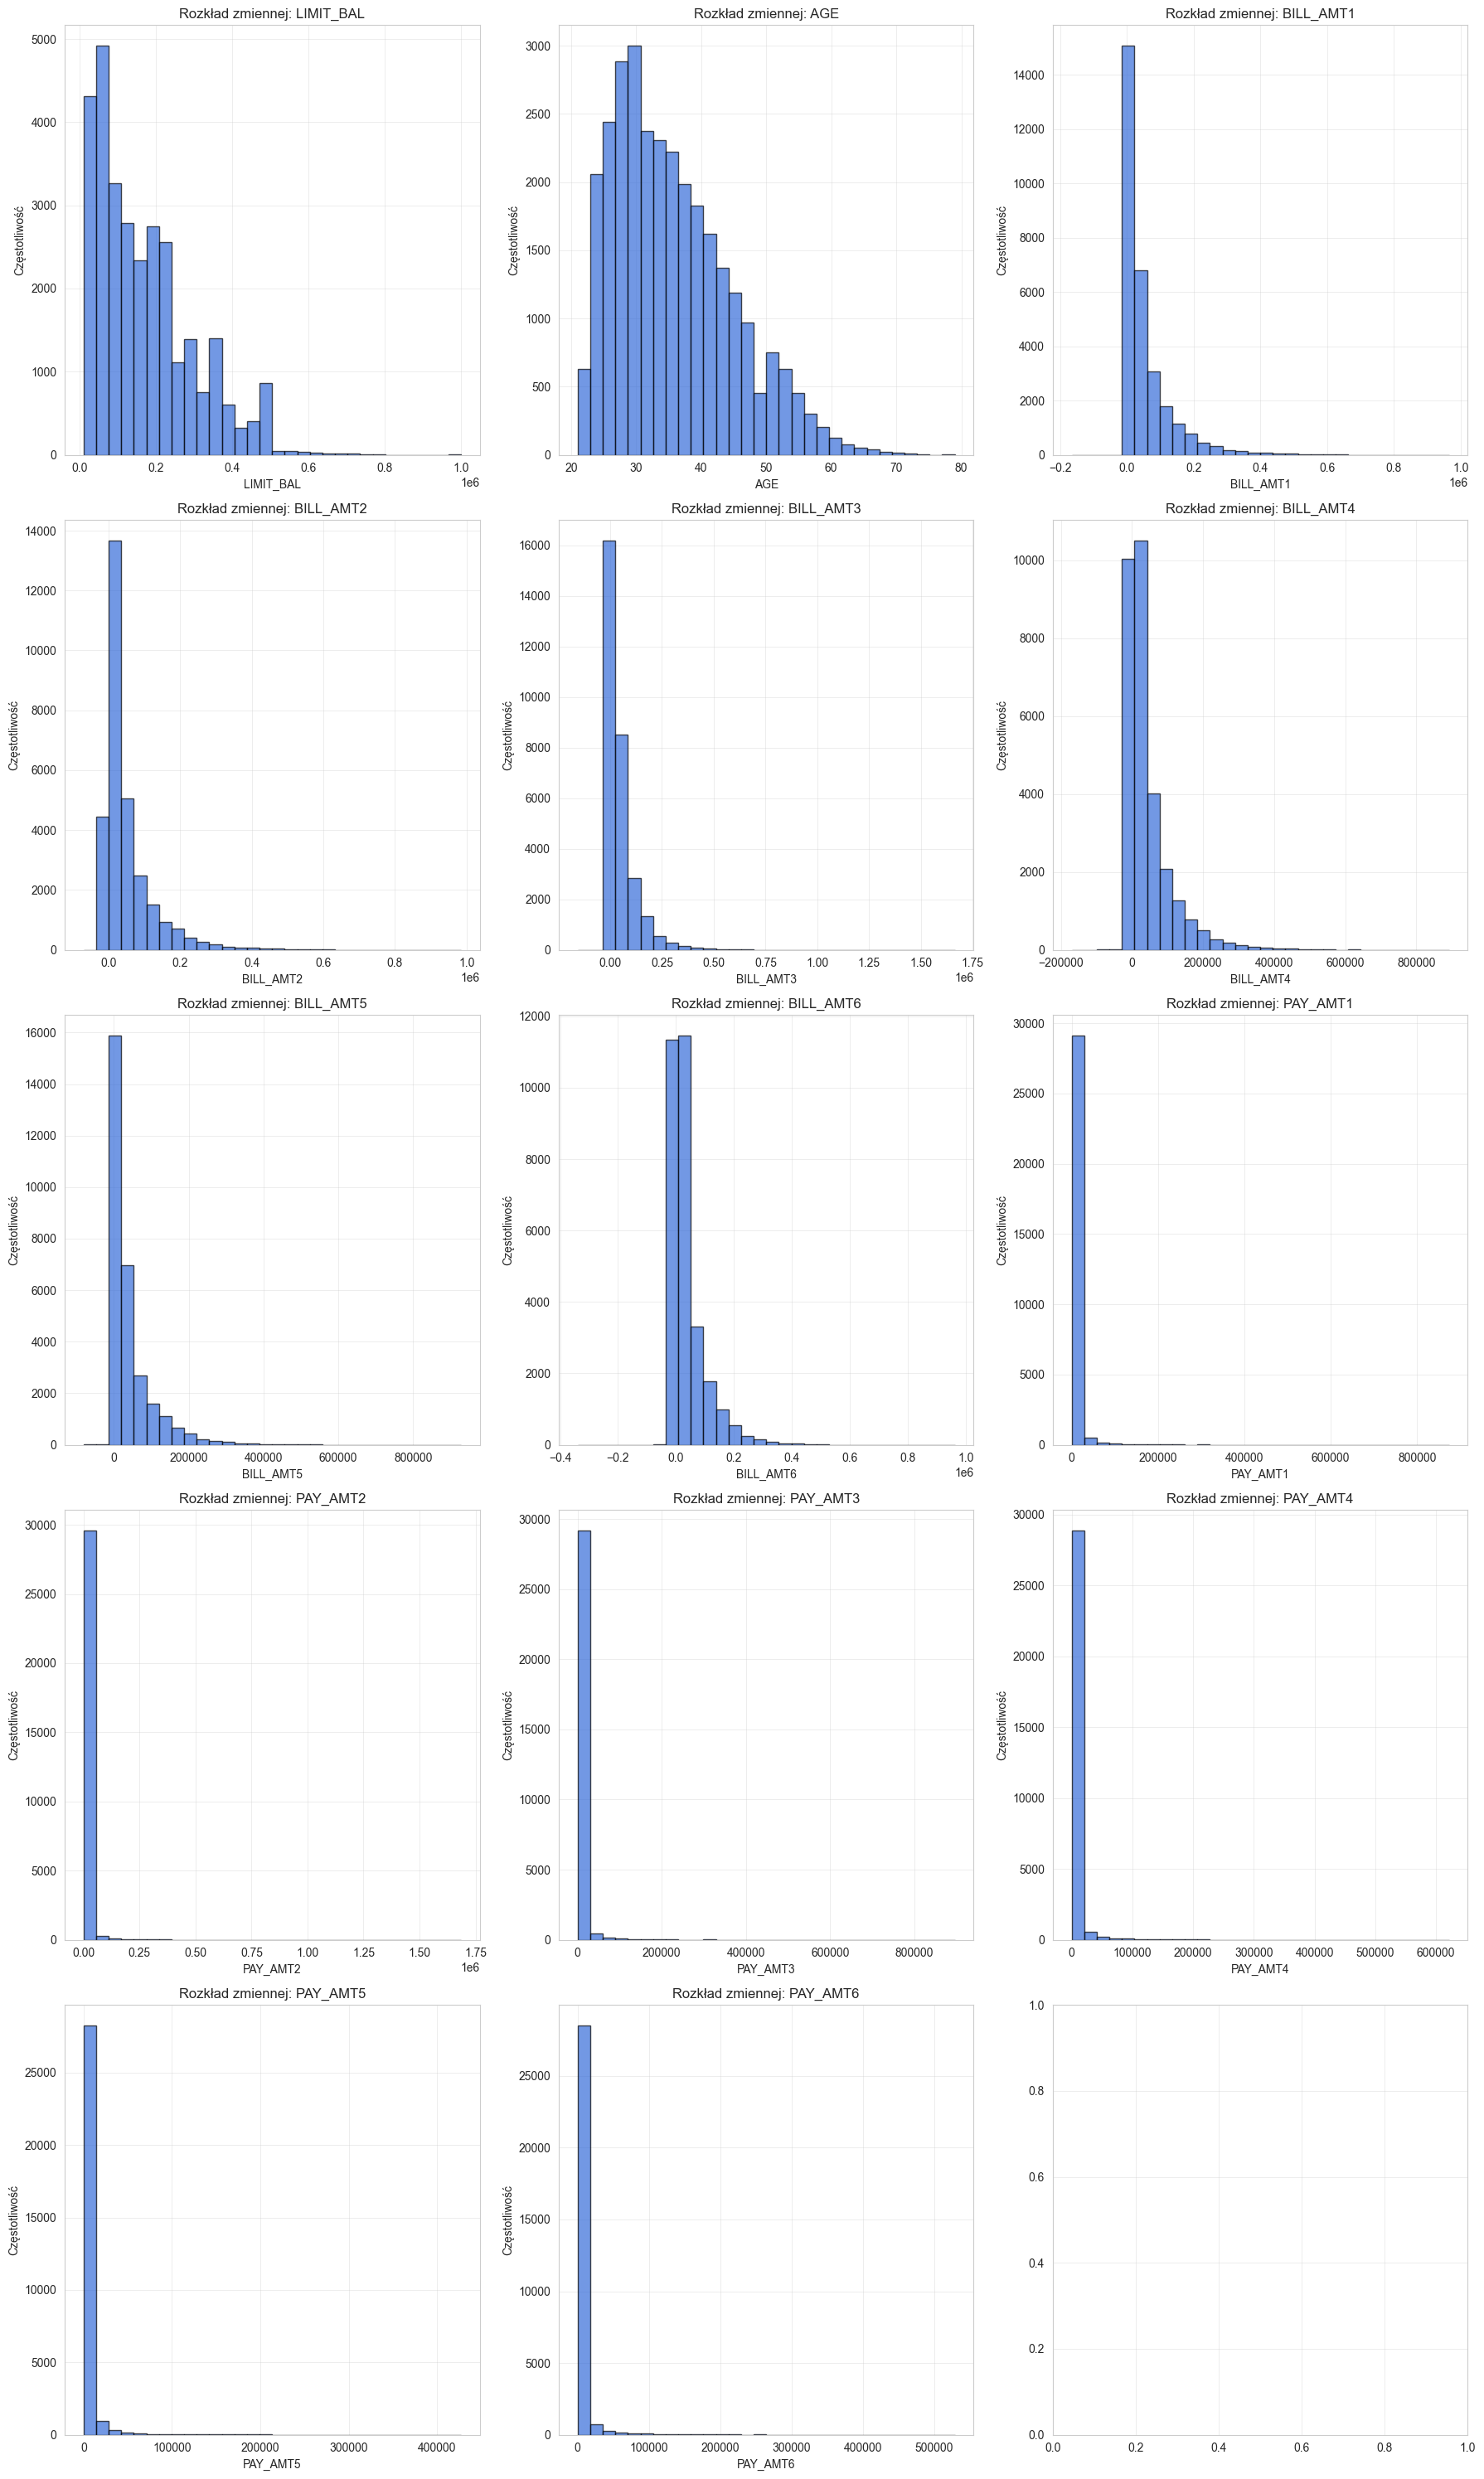

In [70]:
# Histogramy dla zmiennych numerycznych
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

rows = len(numeric_cols) // 3

fig, axes = plt.subplots(rows + 1, 3, figsize=(18, 30))
axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].hist(data[var], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f"Rozkład zmiennej: {var}")
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Częstotliwość")

plt.tight_layout()
plt.show()

# previous_payment_cols = ["X18", "X19", "X20", "X21", "X22", "X23"]

### Identyfikacja wartości odstających (outliers)

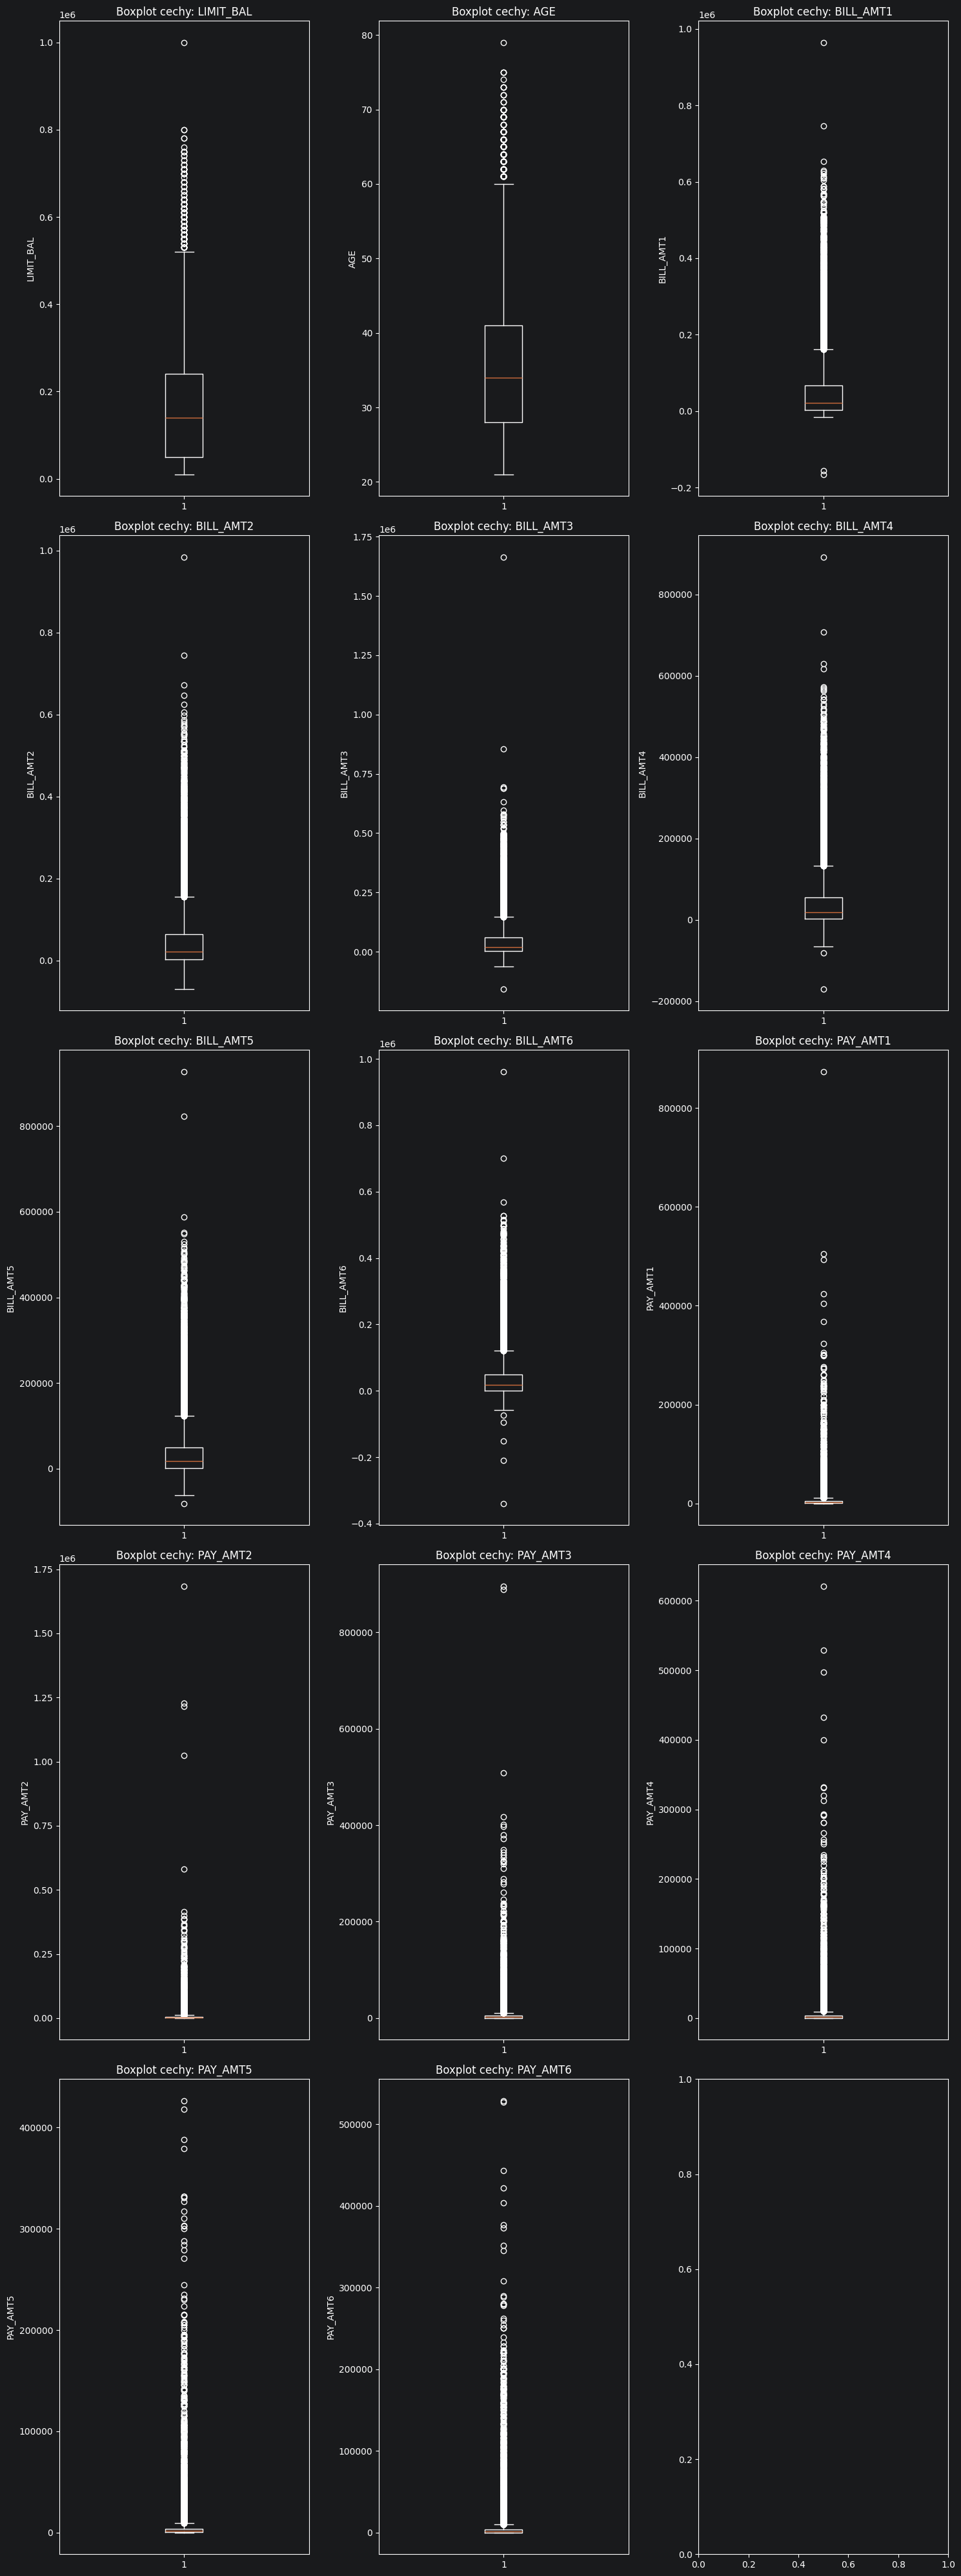

In [72]:
# Boxploty dla zmiennych numerycznych
fig, axes = plt.subplots(rows + 1, 3, figsize=(15, 40))
axes = axes.flatten()

# outlier_vars = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2']
for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].boxplot(data[var])
        axes[i].set_title(f'Boxplot cechy: {var}')
        axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


In [73]:
# Metoda IQR do wykrywania outlierów
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Liczba outlierów (metodą IQR):")
for col in numeric_cols:
    if col in data.columns:
        n_outliers, low, high = count_outliers_iqr(data, col)
        print(f"{col}: {n_outliers} outlierów (zakres: {low:.2f} - {high:.2f})")


Liczba outlierów (metodą IQR):
LIMIT_BAL: 167 outlierów (zakres: -235000.00 - 525000.00)
AGE: 272 outlierów (zakres: 8.50 - 60.50)
BILL_AMT1: 2400 outlierów (zakres: -91741.75 - 162392.25)
BILL_AMT2: 2395 outlierów (zakres: -88551.50 - 155544.50)
BILL_AMT3: 2469 outlierów (zakres: -83579.50 - 146412.50)
BILL_AMT4: 2622 outlierów (zakres: -75943.50 - 132780.50)
BILL_AMT5: 2725 outlierów (zakres: -70885.25 - 122844.75)
BILL_AMT6: 2693 outlierów (zakres: -70660.75 - 121117.25)
PAY_AMT1: 2745 outlierów (zakres: -5009.00 - 11015.00)
PAY_AMT2: 2714 outlierów (zakres: -5417.50 - 11250.50)
PAY_AMT3: 2598 outlierów (zakres: -5782.50 - 10677.50)
PAY_AMT4: 2994 outlierów (zakres: -5280.25 - 9589.75)
PAY_AMT5: 2946 outlierów (zakres: -5414.25 - 9699.75)
PAY_AMT6: 2958 outlierów (zakres: -5705.00 - 9823.00)


### Wykresy rozrzutu (Scatter plots)

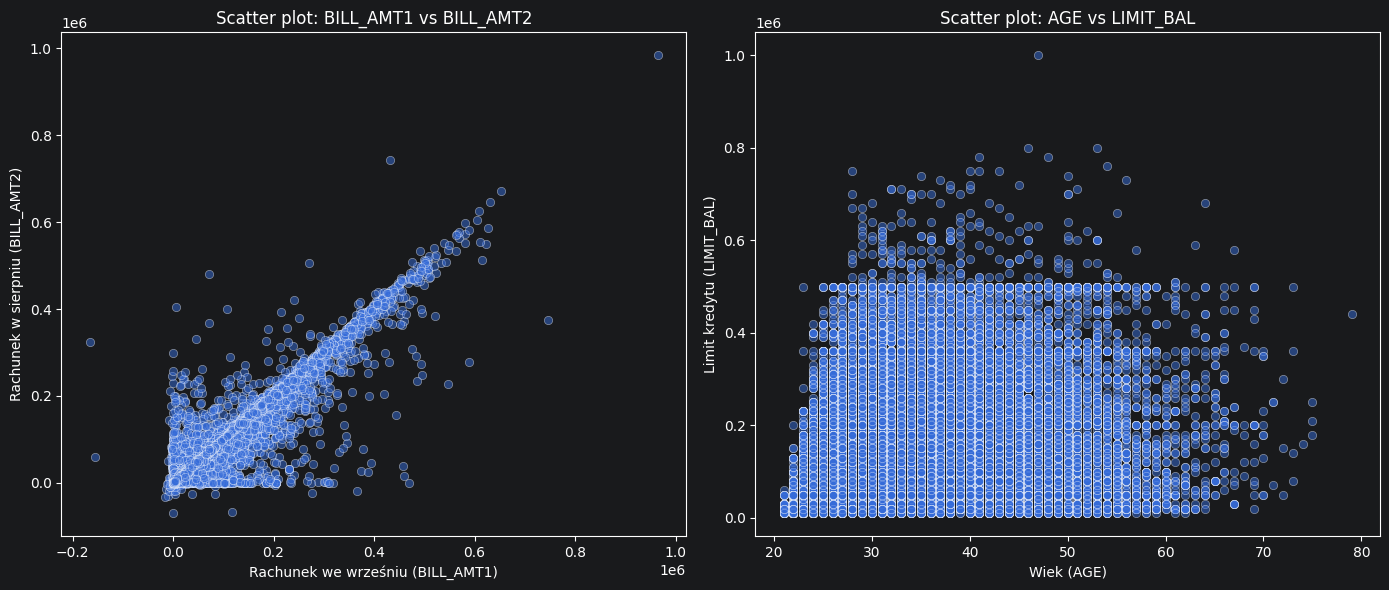

In [74]:
# Wykresy rozrzutu (Scatter plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Przykład 1: Silna korelacja (kwoty rachunków w kolejnych miesiącach)
sns.scatterplot(x=variable_names[12], y=variable_names[13], data=data, alpha=0.5, ax=axes[0])
axes[0].set_title(f'Scatter plot: {variable_names[12]} vs {variable_names[13]}')
axes[0].set_xlabel(f'Rachunek we wrześniu ({variable_names[12]})')
axes[0].set_ylabel(f'Rachunek w sierpniu ({variable_names[13]})')

# Przykład 2: Brak korelacji (Wiek vs Kwota udzielonego kredytu)
sns.scatterplot(x=variable_names[5], y=variable_names[1], data=data, alpha=0.5, ax=axes[1])
axes[1].set_title(f'Scatter plot: {variable_names[5]} vs {variable_names[1]}')
axes[1].set_xlabel(f'Wiek ({variable_names[5]})')
axes[1].set_ylabel(f'Limit kredytu ({variable_names[1]})')

plt.tight_layout()
plt.show()


## Krok 4: Analiza zależności między zmiennymi (korelacje)

In [75]:
# Zmienne dla których będzie wyliczona korelacja
selected_for_corr = numeric_cols + payment_history_features
selected_for_corr.append(variable_names[-1]) # target

selected_for_corr


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'default payment next month']

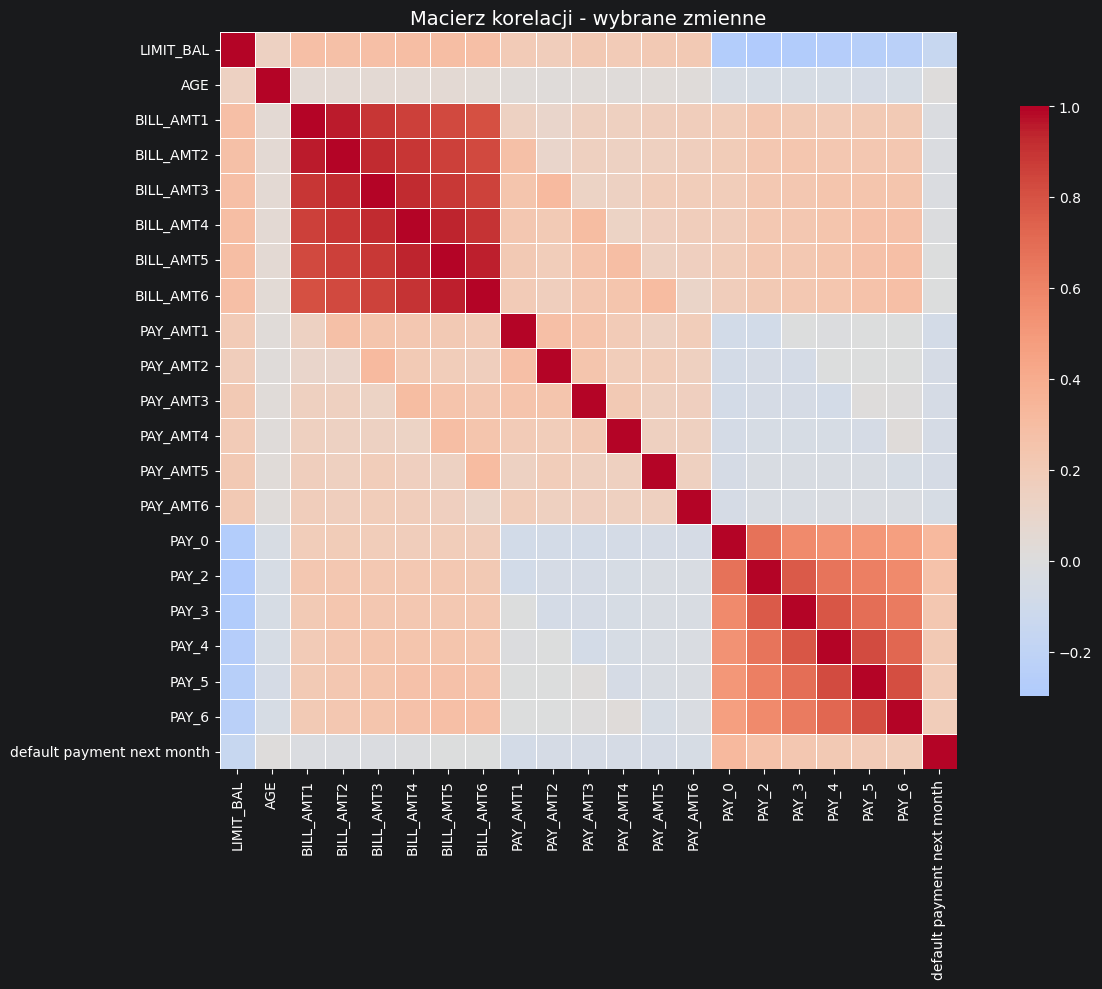

In [76]:
# Macierz korelacji dla wybranych zmiennych
corr_matrix = data[selected_for_corr].corr()

# Heatmapa korelacji
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Macierz korelacji - wybrane zmienne', fontsize=14)
plt.tight_layout()
plt.show()


In [92]:
# Najsilniejsze korelacje ze zmienną docelową
target_corr = corr_matrix[variable_names[-1]].sort_values(ascending=False)

print(f"\nKorelacje ze zmienną docelową ({variable_names[-1]}):")
print(target_corr.drop(labels=[variable_names[-1]]))



Korelacje ze zmienną docelową (default payment next month):
PAY_0        0.324718
PAY_2        0.263469
PAY_3        0.235312
PAY_4        0.216670
PAY_5        0.204265
PAY_6        0.186977
AGE          0.013969
BILL_AMT6   -0.005332
BILL_AMT5   -0.006719
BILL_AMT4   -0.010115
BILL_AMT3   -0.014035
BILL_AMT2   -0.014154
BILL_AMT1   -0.019605
PAY_AMT6    -0.053168
PAY_AMT5    -0.055107
PAY_AMT3    -0.056235
PAY_AMT4    -0.056812
PAY_AMT2    -0.058568
PAY_AMT1    -0.072913
LIMIT_BAL   -0.153461
Name: default payment next month, dtype: float64


## Krok 5: Wstępne obserwacje (Wnioski)

In [93]:
print("=" * 60)
print("WSTĘPNE OBSERWACJE - PODSUMOWANIE")
print("=" * 60)

print("\n1. Podstawowe charakterystyki danych:")
print(f"   - Liczba obserwacji: {len(data)}")
print(f"   - Liczba zmiennych: {len(data.columns)} (w tym {len(cleaned_categorical_variable_names)} nowych oczyszczonych zmiennych)")
print(f"   - Default rate: {data[variable_names[-1]].mean() * 100:.2f}%")

print("\n2. Braki i anomalie:")
print(f"   - Zbiór danych {missing_result} brakujących wartości")
print("    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8")

_display_values_1 = pd.DataFrame(education_not_allowed_values[variable_names[3]].value_counts()).T.columns.tolist()
print(f"    - W EDUCATION występują wartości {_display_values_1} (niestandardowe)")

_display_values_2 = pd.DataFrame(marital_status_not_allowed_values[variable_names[4]].value_counts()).T.columns.tolist()
print(f"    - W MARRIAGE występują wartości {_display_values_2} (niestandardowe)")

print("\n3. Zależności między zmiennymi:")
print("   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą")
print("   - BILL_AMT1...BILL_AMT6 również silnie skorelowane")
print("   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)")

print("\n4. Dalsze przetwarzanie:")
print(f"   - Oczyścić kategorie EDUCATION ({_display_values_1} -> 4)")
print(f"   - Oczyścić kategorie MARRIAGE ({_display_values_2} -> 3)")
print("   - Rozważyć standaryzację dla modeli wrażliwych na skalę")


WSTĘPNE OBSERWACJE - PODSUMOWANIE

1. Podstawowe charakterystyki danych:
   - Liczba obserwacji: 29999
   - Liczba zmiennych: 27 (w tym 2 nowych oczyszczonych zmiennych)
   - Default rate: 22.12%

2. Braki i anomalie:
   - Zbiór danych nie zawiera brakujących wartości
    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8
    - W EDUCATION występują wartości [5, 6, 0] (niestandardowe)
    - W MARRIAGE występują wartości [0] (niestandardowe)

3. Zależności między zmiennymi:
   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą
   - BILL_AMT1...BILL_AMT6 również silnie skorelowane
   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)

4. Dalsze przetwarzanie:
   - Oczyścić kategorie EDUCATION ([5, 6, 0] -> 4)
   - Oczyścić kategorie MARRIAGE ([0] -> 3)
   - Rozważyć standaryzację dla modeli wrażliwych na skalę


# Etap 3. projektu

## Krok 1: Pogłębiona analiza grup (Agregacje i rozkłady warunkowe)

Średnie wartości cech w podziale na wykształcenie (X3):
               X1         X5
X3                          
1   212956.069910  34.231838
2   147062.437634  34.722096
3   126550.270490  40.299980
4   181316.239316  36.143162


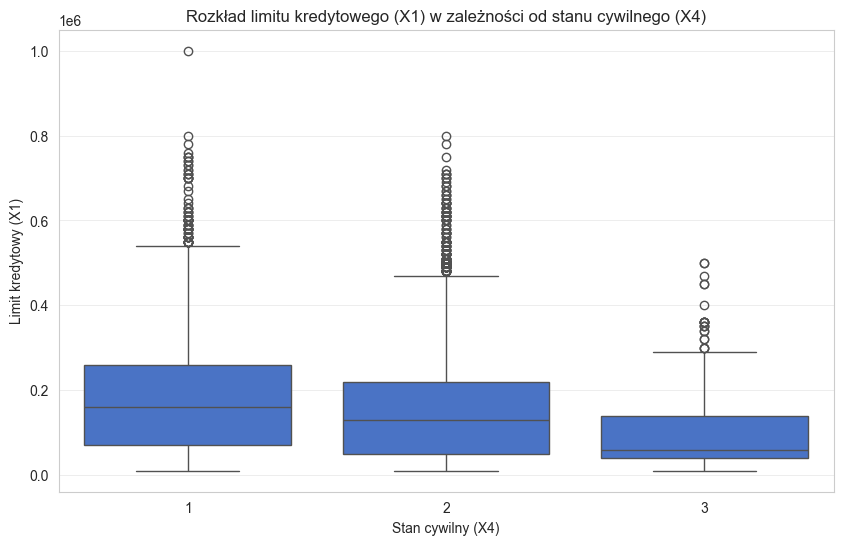

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 'data' to oczyszczony DataFrame z Etapu 2
# Grupowanie: Średni limit kredytowy (X1) i wiek (X5) w zależności od poziomu wykształcenia (X3)
print("Średnie wartości cech w podziale na wykształcenie (X3):")
print(data.groupby('X3')[['X1', 'X5']].mean())
# display(data.groupby('X3')[['X1', 'X5']].mean())

# Wizualizacja rozkładu warunkowego: Wykres pudełkowy limitu kredytowego w zależności od stanu cywilnego (X4)
plt.figure(figsize=(10, 6))
sns.boxplot(x='X4', y='X1', data=data)
plt.title('Rozkład limitu kredytowego (X1) w zależności od stanu cywilnego (X4)')
plt.xlabel('Stan cywilny (X4)')
plt.ylabel('Limit kredytowy (X1)')
plt.show()

## Krok 2: Inżynieria cech (Feature Engineering)

In [27]:
# 1. Sumaryczne zadłużenie z 6 miesięcy (Suma rachunków X12-X17)
bill_cols = ['X12', 'X13', 'X14', 'X15', 'X16', 'X17']
data['TOTAL_BILL'] = data[bill_cols].sum(axis=1)

# 2. Średnie opóźnienie w spłacie (Średnia z cech PAY_* czyli X6-X11)
pay_status_cols = ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']
data['AVG_PAY_DELAY'] = data[pay_status_cols].mean(axis=1)

# 3. Wskaźnik wykorzystania limitu kredytowego (Najnowszy rachunek X12 podzielony przez limit X1)
# Dodanie małej wartości (1e-5), aby uniknąć dzielenia przez zero, jeśli limit wynosiłby 0
data['LIMIT_UTILIZATION'] = data['X12'] / (data['X1'] + 1e-5)

print(data[['TOTAL_BILL', 'AVG_PAY_DELAY', 'LIMIT_UTILIZATION']].head())

   TOTAL_BILL  AVG_PAY_DELAY  LIMIT_UTILIZATION
0        7704      -0.333333           0.195650
1       17077       0.500000           0.022350
2      101653       0.000000           0.324878
3      231334       0.000000           0.939800
4      109339      -0.333333           0.172340


## Krok 3: Kodowanie zmiennych kategorycznych (Categorical Encoding)

In [28]:
# Konwersja kolumn na typ kategoryczny, aby pandas wiedział, co zakodować
categorical_cols = ['X2', 'X3', 'X4']
for col in categorical_cols:
    data[col] = data[col].astype('category')

# Zastosowanie One-Hot Encoding
# drop_first=True zapobiega tzw. pułapce wieloliniowości (usuwa jedną redundantną kolumnę z każdej kategorii)
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print("Kolumny po kodowaniu One-Hot:")
print([col for col in data_encoded.columns if 'X2_' in col or 'X3_' in col or 'X4_' in col])

Kolumny po kodowaniu One-Hot:
['X2_2', 'X3_2', 'X3_3', 'X3_4', 'X4_2', 'X4_3']


Wartości cech `X6`-`X11` (Historia spłat) zostały potraktowane jako zmienne liczbowe, pomino zawierania inforamcji o statusie spłat (inforamcja kategoryczna).
Ponieważ:
- Zastosowanie One-Hot Encoding doprowadziło by do utraty informacji o porządku: One-Hot Encoding traktuje kategorie niezależnie. Algorytm uznałby, że odległość między opóźnieniem o 1 miesiąc (1) a 2 miesiące (2) jest dokładnie taka sama, jak między spłatą terminową (-1) a opóźnieniem o 8 miesięcy (8).
- Kontekst projektu (Klasteryzacja): Na podstawie danych zostaną zbadane algorytmy klastrowania (K-means, Silhouette, itp.). Algorytmy te opierają się na odległościach geometrycznych. Pozostawienie tych cech jako liczb całkowitych (po standaryzacji) pozwala zachować informację, że klient z wartością 3 jest "bliżej" klienta z wartością 2 niż z wartością 8.
- One-Hot Encoding poprawiłby do eksplozji wymiarowości: Każda z 6 zmiennych ma około 11 unikalnych wartości (od -2 do 8). Zastosowanie One-Hot Encoding stworzyłoby ponad 60 nowych, rzadkich (wypełnionych zerami) kolumn.

## Krok 4: Selekcja cech i usuwanie redundancji

In [29]:
# Usuwanie surowych, silnie skorelowanych kolumn rachunków, zostawiając nową cechę zbiorczą TOTAL_BILL
# Usuwanie też ID, które jest tylko indeksem i nie wnosi wartości analitycznej
cols_to_drop = ['ID', 'X13', 'X14', 'X15', 'X16', 'X17']

# Upewniamy się, że nie usuwamy kolumny Y (zmiennej celu), jeśli będzie potrzebna do walidacji,
# ale do samego profilowania/klasteryzacji zazwyczaj odrzuca się również etykietę klasy.
data_selected = data_encoded.drop(columns=cols_to_drop)

print(f"Liczba cech przed selekcją: {data_encoded.shape[1]}")
print(f"Liczba cech po selekcji: {data_selected.shape[1]}")

Liczba cech przed selekcją: 31
Liczba cech po selekcji: 25


## Krok 5: Standaryzacja danych (Feature Scaling)

In [30]:
from sklearn.preprocessing import StandardScaler

# Wybieramy tylko cechy numeryczne do standaryzacji (omijamy zmienne typu bool/one-hot)
# Szukamy kolumn, które nie powstały w wyniku get_dummies i nie są zmienną Y
numeric_features = ['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12',
                    'TOTAL_BILL', 'AVG_PAY_DELAY', 'LIMIT_UTILIZATION']

# Inicjalizacja i dopasowanie scalera
scaler = StandardScaler()
data_scaled = data_selected.copy()

# Nadpisanie wartości numerycznych ich wersją przeskalowaną
data_scaled[numeric_features] = scaler.fit_transform(data_selected[numeric_features])

print("Przykładowe dane po standaryzacji (średnia bliska 0, std=1):")
print(data_scaled[numeric_features].head(3))

Przykładowe dane po standaryzacji (średnia bliska 0, std=1):
         X1        X5        X6        X7        X8        X9       X10  \
0 -1.136720 -1.246020  1.794564  1.782348 -0.696663 -0.666599 -1.530046   
1 -0.365981 -1.029047 -0.874991  1.782348  0.138865  0.188746  0.234917   
2 -0.597202 -0.161156  0.014861  0.111736  0.138865  0.188746  0.234917   

        X11       X12  TOTAL_BILL  AVG_PAY_DELAY  LIMIT_UTILIZATION  
0 -1.486041 -0.642501   -0.690692      -0.153635          -0.554426  
1  1.992316 -0.659219   -0.665997       0.694835          -0.975613  
2  0.253137 -0.298560   -0.443170       0.185753          -0.240351  


## Krok 6: Wizualizacja wyników analizy

### 1. Wykresy zależności między zmiennymi i identyfikacja interakcji

<Figure size 1000x600 with 0 Axes>

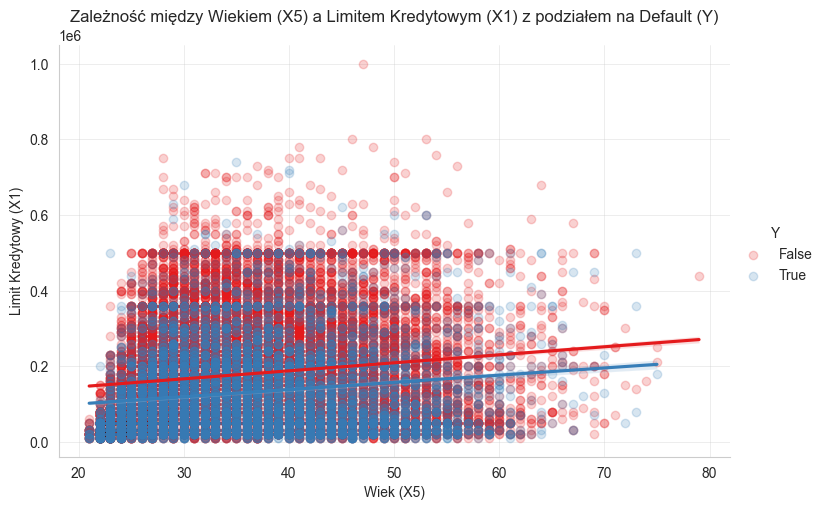

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Tworzymy nową cechę interakcji: Iloczyn wieku i statusu spłaty z ostatniego miesiąca
data['AGE_X_PAY_0'] = data['X5'] * data['X6']

plt.figure(figsize=(10, 6))
# Wykres zależności liniowej limitu od wieku z podziałem na status spłaty (Y)
sns.lmplot(x='X5', y='X1', hue='Y', data=data, palette='Set1', aspect=1.5, scatter_kws={'alpha':0.2})
plt.title('Zależność między Wiekiem (X5) a Limitem Kredytowym (X1) z podziałem na Default (Y)')
plt.xlabel('Wiek (X5)')
plt.ylabel('Limit Kredytowy (X1)')
plt.show()

*Interpretacje wykresu:*
Analizując wykres zależności zaobserwowano, że linie trendu dla obu grup (klienci stabilni vs klienci z defaultem) wykazują tendencję równoległą w obszarze wieku 25-50 lat, jednakże klienci z grupy ryzyka (Y=True) we wszystkich przedziałach wiekowych posiadają wyraźnie niższy średni limit kredytowy (X1).

### 2. Relacje w różnych podzbiorach danych (Analiza grupowa)

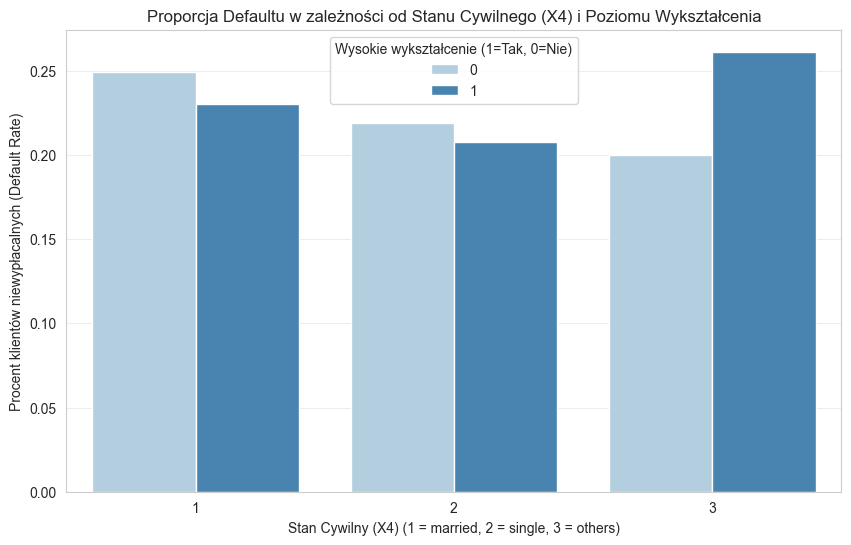

In [32]:
# Tworzenie podzbioru: Osoby z wyższym wykształceniem (X3=1 lub X3=2) vs reszta
data['HIGH_EDU'] = data['X3'].isin([1, 2]).astype(int)

# Wykres grupowy (Barplot) pokazujący procent defaultu w zależności od wykształcenia i stanu cywilnego
plt.figure(figsize=(10, 6))
sns.barplot(x='X4', y='Y', hue='HIGH_EDU', data=data, errorbar=None, palette='Blues')
plt.title('Proporcja Defaultu w zależności od Stanu Cywilnego (X4) i Poziomu Wykształcenia')
plt.xlabel('Stan Cywilny (X4) (1 = married, 2 = single, 3 = others)')
plt.ylabel('Procent klientów niewypłacalnych (Default Rate)')
plt.legend(title='Wysokie wykształcenie (1=Tak, 0=Nie)')
plt.show()

*Interpretacja wykresu:*
...

### 3. Wykresy pokazujące rozkłady warunkowe

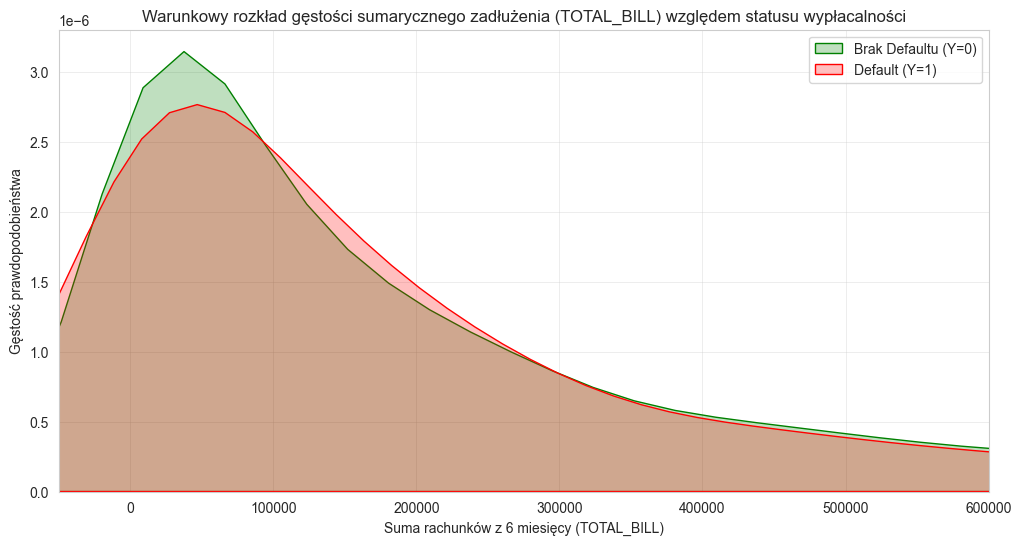

In [33]:
# Wyliczamy sumaryczne zadłużenie (zmienna wprowadzona w Feature Engineering)
# data['TOTAL_BILL'] = data[['X12', 'X13', 'X14', 'X15', 'X16', 'X17']].sum(axis=1)

plt.figure(figsize=(12, 6))
# Rozkład warunkowy gęstości (KDE) sumy rachunków w zależności od zmiennej celu Y
sns.kdeplot(data=data[data['Y']==0], x='TOTAL_BILL', label='Brak Defaultu (Y=0)', fill=True, color='green')
sns.kdeplot(data=data[data['Y']==1], x='TOTAL_BILL', label='Default (Y=1)', fill=True, color='red')
plt.title('Warunkowy rozkład gęstości sumarycznego zadłużenia (TOTAL_BILL) względem statusu wypłacalności')
plt.xlabel('Suma rachunków z 6 miesięcy (TOTAL_BILL)')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.xlim(-50000, 600000) # Ograniczenie osi dla lepszej czytelności (odcięcie skrajnych outlierów)
plt.legend()
plt.show()

*Interpretacja wykresu:*
...

### 4. Wizualizacje wspierające interpretację nowych cech (Feature Engineering)

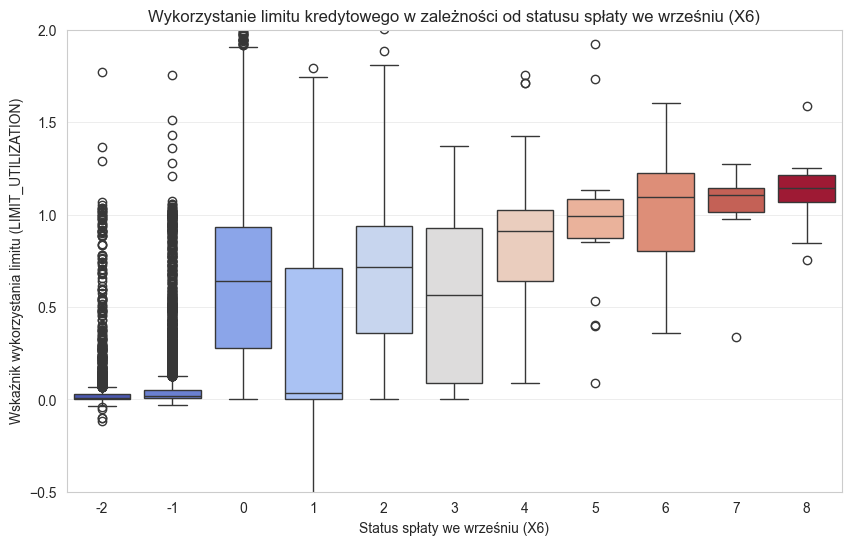

In [34]:
# Tworzenie nowej cechy: Stopień wykorzystania limitu (Bieżący rachunek / Limit)
# data['LIMIT_UTILIZATION'] = data['X12'] / (data['X1'] + 1e-5)

plt.figure(figsize=(10, 6))
# Wykres pudełkowy nowej cechy w podziale na status spłaty z ostatniego miesiąca
sns.boxplot(x='X6', y='LIMIT_UTILIZATION', data=data, palette='coolwarm', hue='X6', legend=False)
plt.title('Wykorzystanie limitu kredytowego w zależności od statusu spłaty we wrześniu (X6)')
plt.xlabel('Status spłaty we wrześniu (X6)')
plt.ylabel('Wskaźnik wykorzystania limitu (LIMIT_UTILIZATION)')
plt.ylim(-0.5, 2.0) # zawężenie widoku, by wyeliminować wpływ pojedynczych anomalii na czytelność boxplota
plt.show()

*Interpretacja wykresu:*
Wprowadzenie nowej zmiennej syntetycznej `LIMIT_UTILIZATION` okazało się kluczowe dla interpretacji zachowań klientów. Wykres pudełkowy pokazuje bezpośrednią zależność: im większe opóźnienie w spłacie (wzrost wartości X6 od 1 do 8), tym wyższa mediana oraz kwartyle wskaźnika wykorzystania limitu. Klienci regularnie spóźniający się z płatnościami eksploatują swoje karty kredytowe blisko maksymalnych limitów (wartości bliskie 1.0 lub wyższe), co stanowi czytelny sygnał ostrzegawczy dla systemów scoringowych.